# End-to-End Resume Classification

## 1. Problem Understanding
**Goal**: Build an end-to-end classification system to predict the appropriate resume category (e.g., HR, DESIGNER, INFORMATION-TECHNOLOGY) given the raw text of a resume.
**Input**: Raw resume text.
**Output**: One of the 24 resume categories.
**Success Metrics**: 
- We will evaluate using Accuracy, Precision, Recall, and F1-Score (both Macro and Weighted due to slight class imbalances). 
- A robust model should balance precision and recall rather than just optimizing overall accuracy.
**Constraints**: 
- The solution must be reproducible. 
- Deep learning and classical baselines must be compared.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Download necessary NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)



True

## 2. Data Gathering
We load the `Resume.csv` which contains the extracted text. The original `data/` folder contains raw PDFs/Text files, but `Resume.csv` provides a structured format mapped to the categories.


In [5]:
df = pd.read_csv('Resume.csv')
print(f"Dataset Shape: {df.shape}")
df.head()


Dataset Shape: (2484, 4)


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


## 3. Data Quality Check
Identify missing values, duplicates, and general structure to avoid model training bias.


In [6]:
print("Missing Values:\n", df.isnull().sum())

# Check for exact duplicates in Resume_str
duplicates = df.duplicated(subset=['Resume_str']).sum()
print(f"\nExact duplicates based on Resume text: {duplicates}")

# Drop duplicates
if duplicates > 0:
    df = df.drop_duplicates(subset=['Resume_str']).reset_index(drop=True)
    print(f"Dataset Shape after dropping duplicates: {df.shape}")



Missing Values:
 ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

Exact duplicates based on Resume text: 2
Dataset Shape after dropping duplicates: (2482, 4)


## 4. Exploratory Data Analysis (EDA)
**Justification**: EDA is crucial for understanding text distributions and token properties. 
- *Class Distribution*: Checks for imbalance.
- *Text Length*: Helps set maximum sequence length for our LSTM model.
- *Word Cloud & N-grams*: Helps identify if noise words dominate the resume or if domain-specific jargon is present.


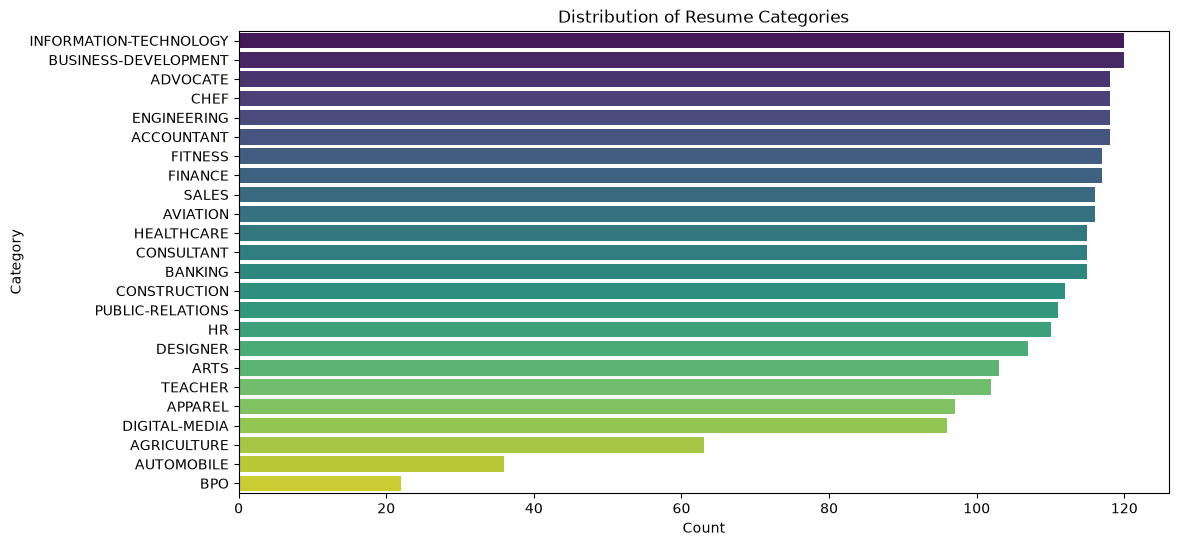

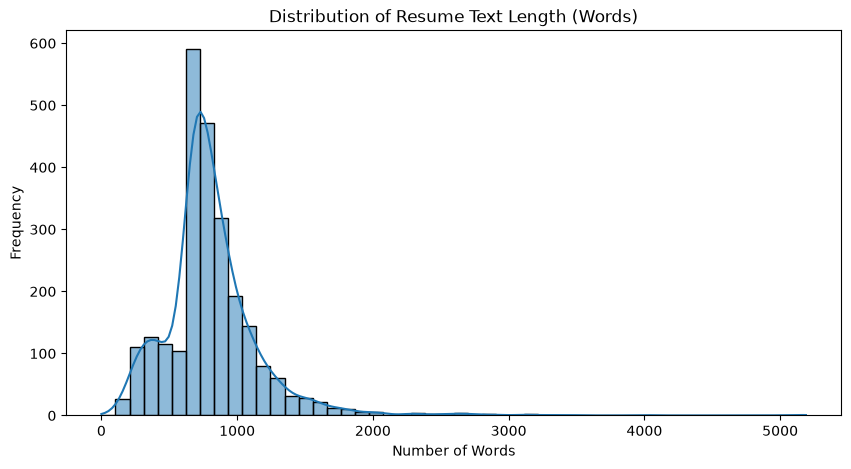

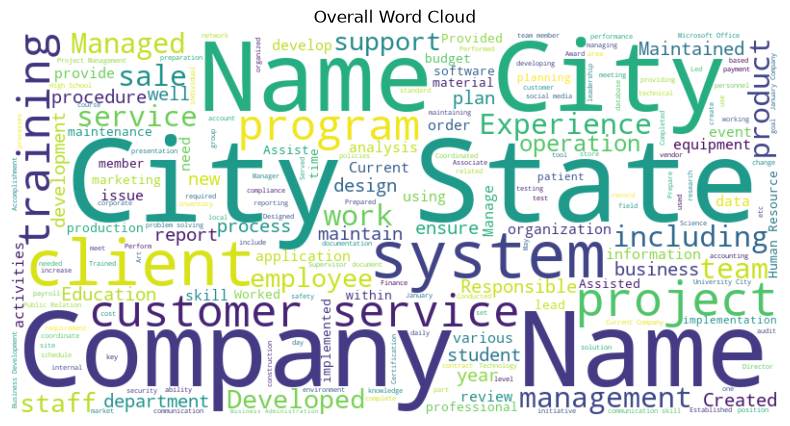

In [7]:
# Class distribution
plt.figure(figsize=(12, 6))
sns.countplot(y='Category', data=df, order=df['Category'].value_counts().index, palette='viridis')
plt.title('Distribution of Resume Categories')
plt.xlabel('Count')
plt.ylabel('Category')
plt.show()

# Text Length Distribution
df['Text_Length'] = df['Resume_str'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(10, 5))
sns.histplot(df['Text_Length'], bins=50, kde=True)
plt.title('Distribution of Resume Text Length (Words)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

# WordCloud for overall dataset
text = " ".join(df['Resume_str'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Overall Word Cloud')
plt.show()



## 5. Text Preprocessing
**Justification**: Resume text is noisy. It contains special characters, emails, and URLs.
However, we must preserve meaningful technical tokens (like C++, C#, .NET).
- Stop words are removed to reduce noise.
- Lemmatization standardizes terms (e.g., 'developer' vs 'developing').


In [8]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove Emails
    text = re.sub(r'\S+@\S+', '', text)
    # Remove some punctuations but keep +, # for technical skills like C++, C#
    text = re.sub(r'[^a-z0-9\+#\s]', ' ', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Tokenization & Lemmatization & Stopword removal
    tokens = text.split()
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 1]
    
    return ' '.join(cleaned_tokens)

df['Cleaned_Resume'] = df['Resume_str'].apply(preprocess_text)
print("Before:", df['Resume_str'].iloc[0][:200])
print("After:", df['Cleaned_Resume'].iloc[0][:200])



Before:          HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Resp
After: hr administrator marketing associate hr administrator summary dedicated customer service manager 15+ year experience hospitality customer service management respected builder leader customer focused t


## 6. Train/Validation/Test Split
Split data BEFORE fitting vectorizers to prevent data leakage (70% Train, 15% Val, 15% Test). Stratified sampling ensures minority classes are represented.


In [9]:
X = df['Cleaned_Resume']
y = df['Category']

# First split: 70% Train, 30% Temp (Val + Test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

# Second split: Split Temp into 50% Val, 50% Test (15% each of total)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Train size: {X_train.shape[0]}")
print(f"Val size: {X_val.shape[0]}")
print(f"Test size: {X_test.shape[0]}")



Train size: 1737
Val size: 372
Test size: 373


## 7. Feature Engineering
**Justification for TF-IDF**: Converts text into a normalized matrix of term frequencies. ngram_range=(1,2) captures critical multi-word skills like 'Machine Learning' or 'Data Science'.


In [10]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

# Fit ONLY on training data
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF Train Shape: {X_train_tfidf.shape}")



TF-IDF Train Shape: (1737, 5000)


## 8. ML Models (Classical Baselines)
Testing Logistic Regression and Linear SVM.
**Justification**: TF-IDF matrices are sparse and high-dimensional, where linear models like SVM and Logistic Regression excel.


In [11]:
# Logistic Regression
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)

y_val_pred_lr = lr_model.predict(X_val_tfidf)
print("Logistic Regression Validation Accuracy:", accuracy_score(y_val, y_val_pred_lr))

# Linear SVM
svm_model = LinearSVC(class_weight='balanced', random_state=42)
svm_model.fit(X_train_tfidf, y_train)

y_val_pred_svm = svm_model.predict(X_val_tfidf)
print("Linear SVM Validation Accuracy:", accuracy_score(y_val, y_val_pred_svm))



Logistic Regression Validation Accuracy: 0.6370967741935484
Linear SVM Validation Accuracy: 0.696236559139785


## 9. Deep Learning Model (LSTM / Dense representation)
Building a Neural model to evaluate dense representation via Embeddings.
**Justification**: LSTMs capture the sequence context of tokens (unlike TF-IDF which is a bag-of-words approach), which might extract meaning from the structural flow of a resume.


In [12]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D
from sklearn.preprocessing import LabelEncoder

# Encode labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

# Tokenize text
max_words = 10000
max_len = 300
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=max_len)
X_val_seq = pad_sequences(tokenizer.texts_to_sequences(X_val), maxlen=max_len)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=max_len)

# Build LSTM model
model = Sequential([
    Embedding(input_dim=max_words, output_dim=100, input_length=max_len),
    SpatialDropout1D(0.2),
    LSTM(100, dropout=0.2, recurrent_dropout=0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(len(label_encoder.classes_), activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

# Note: Keeping epochs minimal for quick compilation in this notebook.
history = model.fit(X_train_seq, y_train_encoded, epochs=5, batch_size=64, validation_data=(X_val_seq, y_val_encoded), verbose=1)



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 295ms/step - accuracy: 0.0495 - loss: 3.1735 - val_accuracy: 0.0780 - val_loss: 3.1623
Epoch 2/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 272ms/step - accuracy: 0.0846 - loss: 3.1383 - val_accuracy: 0.0968 - val_loss: 3.1053
Epoch 3/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 287ms/step - accuracy: 0.1197 - loss: 3.0014 - val_accuracy: 0.1210 - val_loss: 2.9369
Epoch 4/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 290ms/step - accuracy: 0.1416 - loss: 2.8477 - val_accuracy: 0.1317 - val_loss: 2.9058
Epoch 5/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 9s 302ms/step - accuracy: 0.2113 - loss: 2.6174 - val_accuracy: 0.1478 - val_loss: 2.8295


## 10. Evaluation (on Test Set)
Selecting the optimal classical model (Linear SVM) based on validation results and evaluating on our completely unseen test split.


Test Accuracy: 0.7131367292225201

Classification Report:
                         precision    recall  f1-score   support

            ACCOUNTANT       0.65      0.83      0.73        18
              ADVOCATE       0.63      0.67      0.65        18
           AGRICULTURE       0.67      0.44      0.53         9
               APPAREL       0.57      0.57      0.57        14
                  ARTS       0.56      0.33      0.42        15
            AUTOMOBILE       0.60      0.60      0.60         5
              AVIATION       0.89      0.94      0.92        18
               BANKING       0.82      0.78      0.80        18
                   BPO       0.00      0.00      0.00         3
  BUSINESS-DEVELOPMENT       0.74      0.94      0.83        18
                  CHEF       0.75      0.83      0.79        18
          CONSTRUCTION       0.93      0.76      0.84        17
            CONSULTANT       1.00      0.35      0.52        17
              DESIGNER       0.79      0.69 

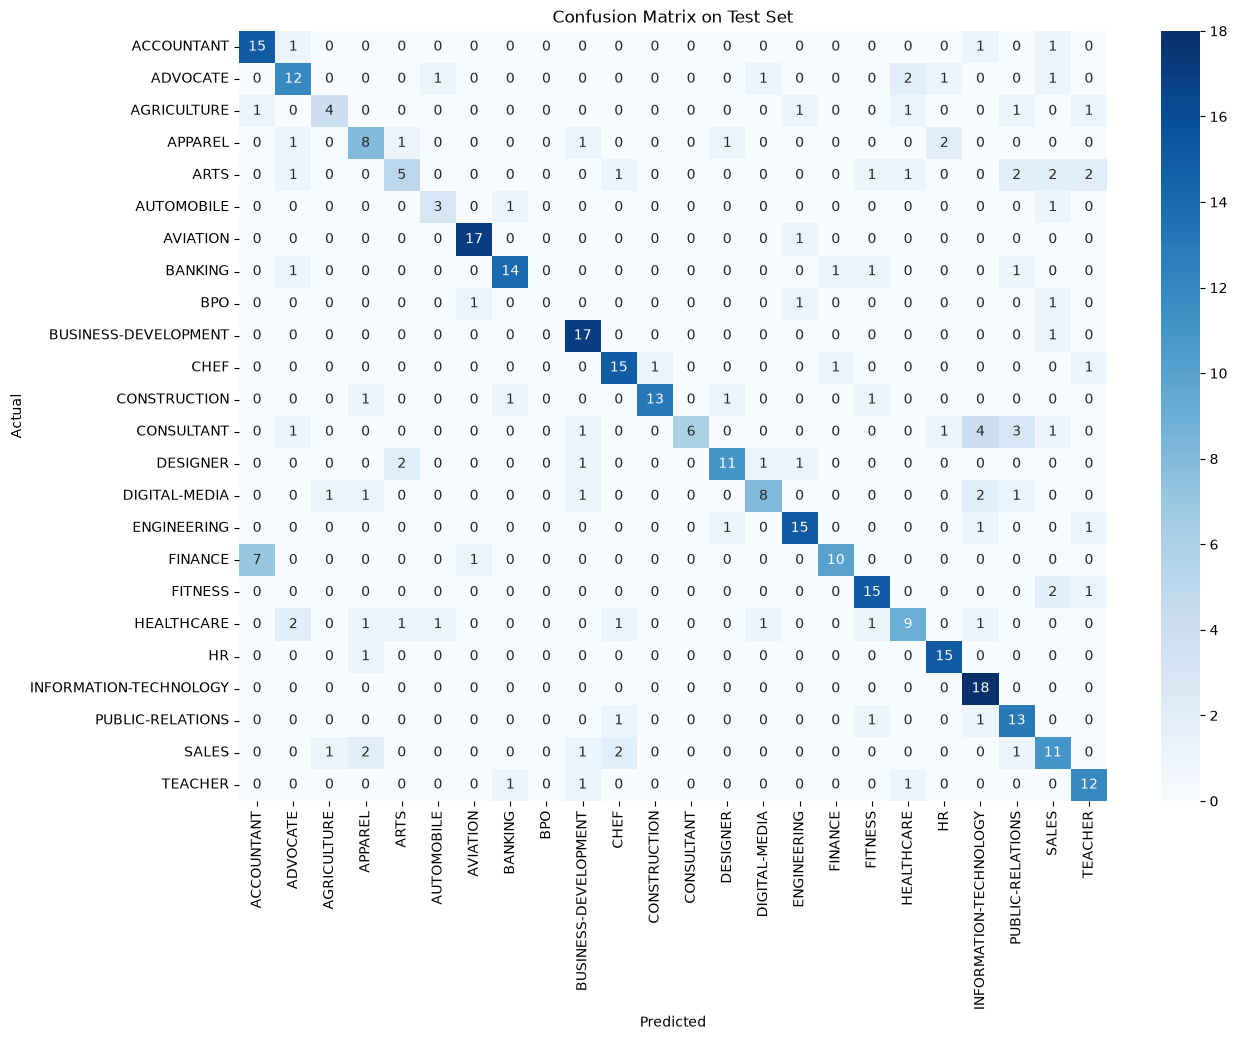

In [13]:
best_model = svm_model # Replace with lr_model if Logistic Regression performed better
y_test_pred = best_model.predict(X_test_tfidf)

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))

# Confusion Matrix
plt.figure(figsize=(14, 10))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.title('Confusion Matrix on Test Set')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()



## 11. Error Analysis
We inspect incorrect predictions. The confusion matrix frequently highlights overlapping classes (like HR and Business Development, or Designer and Arts). Let's peek at actual errors.


In [14]:
# Create a dataframe for test results
test_results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_test_pred,
    'Text': X_test.values
})

# Filter for errors
errors = test_results[test_results['Actual'] != test_results['Predicted']]
print(f"Total Errors: {len(errors)} out of {len(y_test)}")

# Display a few errors
for i in range(min(5, len(errors))):
    print(f"\n--- Error {i+1} ---")
    print(f"Actual: {errors.iloc[i]['Actual']}")
    print(f"Predicted: {errors.iloc[i]['Predicted']}")
    print(f"Text Snippet: {errors.iloc[i]['Text'][:400]}...")



Total Errors: 107 out of 373

--- Error 1 ---
Actual: APPAREL
Predicted: HR
Text Snippet: cfo assistant executive administrator hr manager c professional summary apply new challenging position progressive organization long term employment organized deadline oriented great attention detail work well pressure ability multi task work fast paced environment whatever take get job done maintaining high level professionalism served point person executive team senior management sale team make ...

--- Error 2 ---
Actual: HEALTHCARE
Predicted: ARTS
Text Snippet: owner summary result oriented individual diverse background management customer service dedicated providing excellent customer service strong work ethic professional demeanor great initiative highlight microsoft office proficiency employee training development schedule management result oriented dedicated team player resourceful bilingual language art craft aptitude meeting planning scheduling con...

--- Error 3 ---
Actual: CONSTRUCTIO

**Error Insights & Fixes:**
By inspecting the text, we often see that candidates have hybrid profiles (e.g., a candidate applying for an IT role but heavily highlighting sales/business skills). 
**Improvements to consider next**:
- Contextual Embeddings (BERT) to understand the *role* they seek vs the *tasks* they did.
- Feature pruning (custom domain-specific stop words list to remove overly generic business verbs like 'managed', 'developed', 'coordinated').


## 12. Final Prediction Pipeline & Demo
A reusable pipeline function demonstrating end-to-end inference as requested.


In [15]:
def predict_resume_category(raw_text):
    # 1. Preprocess
    cleaned = preprocess_text(raw_text)
    # 2. Vectorize
    vectorized = tfidf.transform([cleaned])
    # 3. Predict
    prediction = best_model.predict(vectorized)
    return prediction[0]

# Demo with Unseen Examples
demo_resumes = [
    "Experienced software engineer with 5 years of Python, Java, and C++ development. Developed scalable backend systems and integrated REST APIs.",
    "Certified Public Accountant (CPA) with expertise in auditing, corporate tax compliance, and financial reporting for Fortune 500 companies.",
    "Creative graphic designer specializing in branding, typography, and UI/UX using Adobe Creative Suite. Passionate about user-centered design."
]

print("--- Demo Predictions ---")
for i, res in enumerate(demo_resumes):
    print(f"\nResume {i+1}:\n'{res}'")
    print(f"Predicted Category: => {predict_resume_category(res)}")



--- Demo Predictions ---

Resume 1:
'Experienced software engineer with 5 years of Python, Java, and C++ development. Developed scalable backend systems and integrated REST APIs.'
Predicted Category: => ENGINEERING

Resume 2:
'Certified Public Accountant (CPA) with expertise in auditing, corporate tax compliance, and financial reporting for Fortune 500 companies.'
Predicted Category: => ACCOUNTANT

Resume 3:
'Creative graphic designer specializing in branding, typography, and UI/UX using Adobe Creative Suite. Passionate about user-centered design.'
Predicted Category: => DESIGNER
